# FIFA World Cup (1994–2022): Squad Value, Age Structure, and 2026 Champion Forecast

This notebook follows the modeling workflow described in the project brief:

- **Panel unit**: national team × World Cup edition.
- **Lines**: `front`, `mid`, `back`, `gk` (Transfermark-style market values in **million EUR**); **ages** are **value-weighted** averages within each line.
- **Dynamics**: log changes vs the previous edition (`dlog_*`) and age changes (`d_*`), with **NA** for teams that did not play the previous tournament (imputed by **confederation median** in this implementation).
- **Within-tournament standardization**: z-scores computed **separately for each World Cup year** for levels, changes, and quadratic age terms.
- **Outcome A — continuous**: `result_score` maps **champion → 1**, **last place → 0**, linearly by elimination rank.
- **Outcome B — champion choice**: **softmax** over a linear index \(s_{i,t}\) with the same feature family (plus intercept).

**Data note:** This study uses **World Cup participating teams from 1994 to 2022** as the primary data source. Teams are divided into four positional groups: forward, midfield, defense, and goalkeeper. For each group, total positional market value and value-weighted average age are calculated, along with cross-tournament changes in log market value and age. Market values for 1994–2006 are estimated via historical back-calculation, while post-2008 values are derived from authoritative market data. Tournament performance is standardized with the champion coded as 1 and the lowest-ranked team as 0. All variables are standardized using **Z-score** within each World Cup edition prior to modeling.




In [1]:
# Configuration
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

BASE = Path(r"d:\学习\MEM\5559").resolve()
OUT_DIR = BASE / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Set to a CSV path to override synthetic data (must contain at least: year, team, finish_rank,
# front_value_m, mid_value_m, back_value_m, gk_value_m, confed)
DATA_PATH = None  # e.g. BASE / "wc_team_panel_raw.csv"

RNG_SEED = 42
np.random.seed(RNG_SEED)


## 1. Champion “next tournament” table (from project document)

In [2]:
champion_records = [
    dict(champion_year=1994, team="Brazil", next_year=1998, next_stage="RunnerUp", next_stage_ordinal=5,
         front_value_win_m=110, mid_value_win_m=70, back_value_win_m=60, gk_value_win_m=20, total_value_win_m=260,
         front_age_win=27.4, mid_age_win=27.8, back_age_win=29.1, gk_age_win=30.8, overall_age_win=28.2,
         front_value_next_m=170, mid_value_next_m=100, back_value_next_m=90, gk_value_next_m=30, total_value_next_m=390,
         front_age_next=28.2, mid_age_next=28.4, back_age_next=29.4, gk_age_next=31.0, overall_age_next=28.8),
    dict(champion_year=1998, team="France", next_year=2002, next_stage="Group", next_stage_ordinal=1,
         front_value_win_m=130, mid_value_win_m=140, back_value_win_m=115, gk_value_win_m=35, total_value_win_m=420,
         front_age_win=26.8, mid_age_win=27.9, back_age_win=29.2, gk_age_win=28.0, overall_age_win=28.0,
         front_value_next_m=170, mid_value_next_m=160, back_value_next_m=130, gk_value_next_m=40, total_value_next_m=500,
         front_age_next=28.7, mid_age_next=29.0, back_age_next=30.1, gk_age_next=30.0, overall_age_next=29.3),
    dict(champion_year=2002, team="Brazil", next_year=2006, next_stage="QF", next_stage_ordinal=3,
         front_value_win_m=240, mid_value_win_m=140, back_value_win_m=110, gk_value_win_m=40, total_value_win_m=530,
         front_age_win=27.9, mid_age_win=27.4, back_age_win=28.1, gk_age_win=29.0, overall_age_win=27.8,
         front_value_next_m=250, mid_value_next_m=180, back_value_next_m=120, gk_value_next_m=40, total_value_next_m=590,
         front_age_next=29.1, mid_age_next=28.2, back_age_next=28.9, gk_age_next=33.0, overall_age_next=29.2),
    dict(champion_year=2006, team="Italy", next_year=2010, next_stage="Group", next_stage_ordinal=1,
         front_value_win_m=150, mid_value_win_m=180, back_value_win_m=190, gk_value_win_m=40, total_value_win_m=560,
         front_age_win=29.3, mid_age_win=29.0, back_age_win=30.2, gk_age_win=28.2, overall_age_win=29.5,
         front_value_next_m=120, mid_value_next_m=150, back_value_next_m=200, gk_value_next_m=40, total_value_next_m=510,
         front_age_next=30.8, mid_age_next=30.4, back_age_next=32.1, gk_age_next=32.0, overall_age_next=31.2),
    dict(champion_year=2010, team="Spain", next_year=2014, next_stage="Group", next_stage_ordinal=1,
         front_value_win_m=210, mid_value_win_m=270, back_value_win_m=170, gk_value_win_m=40, total_value_win_m=690,
         front_age_win=26.2, mid_age_win=27.8, back_age_win=28.1, gk_age_win=29.1, overall_age_win=27.5,
         front_value_next_m=240, mid_value_next_m=280, back_value_next_m=190, gk_value_next_m=50, total_value_next_m=760,
         front_age_next=28.3, mid_age_next=29.2, back_age_next=29.4, gk_age_next=33.2, overall_age_next=29.1),
    dict(champion_year=2014, team="Germany", next_year=2018, next_stage="Group", next_stage_ordinal=1,
         front_value_win_m=240, mid_value_win_m=290, back_value_win_m=240, gk_value_win_m=50, total_value_win_m=820,
         front_age_win=26.8, mid_age_win=27.6, back_age_win=28.4, gk_age_win=28.0, overall_age_win=27.6,
         front_value_next_m=250, mid_value_next_m=300, back_value_next_m=300, gk_value_next_m=50, total_value_next_m=900,
         front_age_next=28.7, mid_age_next=29.0, back_age_next=30.1, gk_age_next=32.0, overall_age_next=29.3),
    dict(champion_year=2018, team="France", next_year=2022, next_stage="RunnerUp", next_stage_ordinal=5,
         front_value_win_m=430, mid_value_win_m=290, back_value_win_m=300, gk_value_win_m=60, total_value_win_m=1080,
         front_age_win=24.8, mid_age_win=26.5, back_age_win=26.9, gk_age_win=31.8, overall_age_win=26.6,
         front_value_next_m=400, mid_value_next_m=280, back_value_next_m=300, gk_value_next_m=60, total_value_next_m=1040,
         front_age_next=26.4, mid_age_next=27.8, back_age_next=27.7, gk_age_next=29.0, overall_age_next=27.3),
    dict(champion_year=2022, team="Argentina", next_year=2026, next_stage="TBD", next_stage_ordinal=np.nan,
         front_value_win_m=260, mid_value_win_m=190, back_value_win_m=170, gk_value_win_m=40, total_value_win_m=660,
         front_age_win=26.7, mid_age_win=27.9, back_age_win=28.6, gk_age_win=30.2, overall_age_win=27.8,
         front_value_next_m=np.nan, mid_value_next_m=np.nan, back_value_next_m=np.nan, gk_value_next_m=np.nan, total_value_next_m=np.nan,
         front_age_next=np.nan, mid_age_next=np.nan, back_age_next=np.nan, gk_age_next=np.nan, overall_age_next=np.nan),
]

champion_df = pd.DataFrame(champion_records)
champion_df.to_csv(OUT_DIR / "champion_next_tournament.csv", index=False)
display(champion_df)


,champion_year,team,next_year,next_stage,next_stage_ordinal,front_value_win_m,mid_value_win_m,back_value_win_m,gk_value_win_m,total_value_win_m,...,front_value_next_m,mid_value_next_m,back_value_next_m,gk_value_next_m,total_value_next_m,front_age_next,mid_age_next,back_age_next,gk_age_next,overall_age_next
0,1994,Brazil,1998,RunnerUp,5.0,110,70,60,20,260,...,170.0,100.0,90.0,30.0,390.0,28.2,28.4,29.4,31.0,28.8
1,1998,France,2002,Group,1.0,130,140,115,35,420,...,170.0,160.0,130.0,40.0,500.0,28.7,29.0,30.1,30.0,29.3
2,2002,Brazil,2006,QF,3.0,240,140,110,40,530,...,250.0,180.0,120.0,40.0,590.0,29.1,28.2,28.9,33.0,29.2
3,2006,Italy,2010,Group,1.0,150,180,190,40,560,...,120.0,150.0,200.0,40.0,510.0,30.8,30.4,32.1,32.0,31.2
4,2010,Spain,2014,Group,1.0,210,270,170,40,690,...,240.0,280.0,190.0,50.0,760.0,28.3,29.2,29.4,33.2,29.1
5,2014,Germany,2018,Group,1.0,240,290,240,50,820,...,250.0,300.0,300.0,50.0,900.0,28.7,29.0,30.1,32.0,29.3
6,2018,France,2022,RunnerUp,5.0,430,290,300,60,1080,...,400.0,280.0,300.0,60.0,1040.0,26.4,27.8,27.7,29.0,27.3
7,2022,Argentina,2026,TBD,NaN,260,190,170,40,660,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Build (or load) the team×year panel

If `DATA_PATH` is `None`, a **synthetic** panel is simulated so ranks, values, and ages co-move realistically; **winners match actual champions**.

In [3]:
CONFED_MAP = {
    "Brazil": "CONMEBOL", "Argentina": "CONMEBOL", "Uruguay": "CONMEBOL", "Colombia": "CONMEBOL",
    "Ecuador": "CONMEBOL", "Paraguay": "CONMEBOL", "Chile": "CONMEBOL", "Peru": "CONMEBOL",
    "France": "UEFA", "Germany": "UEFA", "Spain": "UEFA", "Italy": "UEFA", "England": "UEFA",
    "Portugal": "UEFA", "Netherlands": "UEFA", "Belgium": "UEFA", "Croatia": "UEFA",
    "Norway": "UEFA", "Switzerland": "UEFA", "Scotland": "UEFA", "Austria": "UEFA",
    "Sweden": "UEFA", "Türkiye": "UEFA", "Turkey": "UEFA", "Czechia": "UEFA", "Czech Republic": "UEFA",
    "Bosnia and Herzegovina": "UEFA", "Poland": "UEFA", "Ukraine": "UEFA", "Denmark": "UEFA",
    "Serbia": "UEFA", "Russia": "UEFA", "Wales": "UEFA", "Slovakia": "UEFA", "Hungary": "UEFA",
    "Romania": "UEFA", "Bulgaria": "UEFA", "Greece": "UEFA", "Ireland": "UEFA",
    "Mexico": "CONCACAF", "United States": "CONCACAF", "USA": "CONCACAF", "Canada": "CONCACAF",
    "Panama": "CONCACAF", "Costa Rica": "CONCACAF", "Honduras": "CONCACAF", "Jamaica": "CONCACAF",
    "Curaçao": "CONCACAF", "Curacao": "CONCACAF", "Haiti": "CONCACAF",
    "Japan": "AFC", "South Korea": "AFC", "Korea Republic": "AFC", "Australia": "AFC", "Iran": "AFC",
    "Saudi Arabia": "AFC", "Qatar": "AFC", "Uzbekistan": "AFC", "Jordan": "AFC", "Iraq": "AFC",
    "China PR": "AFC",
    "Morocco": "CAF", "Senegal": "CAF", "Nigeria": "CAF", "Ghana": "CAF", "Egypt": "CAF",
    "Algeria": "CAF", "Tunisia": "CAF", "Cameroon": "CAF", "Ivory Coast": "CAF", "Côte d'Ivoire": "CAF",
    "South Africa": "CAF", "Cape Verde": "CAF", "DR Congo": "CAF",
    "New Zealand": "OFC",
}


def confed(team: str) -> str:
    return CONFED_MAP.get(team, "UEFA")


def build_synthetic_panel(seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    years = [1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]
    n_teams = {1994: 24, 1998: 32, 2002: 32, 2006: 32, 2010: 32, 2014: 32, 2018: 32, 2022: 32}
    winners = {
        1994: "Brazil",
        1998: "France",
        2002: "Brazil",
        2006: "Italy",
        2010: "Spain",
        2014: "Germany",
        2018: "France",
        2022: "Argentina",
    }
    pool = sorted(
        set(CONFED_MAP.keys())
        | {
            "Cameroon",
            "Costa Rica",
            "Sweden",
            "Romania",
            "Bulgaria",
            "Nigeria",
            "Paraguay",
            "Turkey",
            "China PR",
            "Angola",
            "Togo",
            "Trinidad and Tobago",
            "Saudi Arabia",
            "Russia",
            "Ukraine",
            "Serbia",
            "Slovakia",
            "Denmark",
            "Poland",
            "Iceland",
            "Panama",
            "Peru",
        }
    )

    prev_snapshot = {}  # team -> dict of levels for deltas
    rows = []

    for year in years:
        n = n_teams[year]
        w = winners[year]
        others = [c for c in pool if c != w]
        rng.shuffle(others)
        teams = [w] + others[: n - 1]
        rng.shuffle(teams)

        ranks = np.empty(n, dtype=int)
        perm = rng.permutation(n) + 1
        wi = teams.index(w)
        j = int(np.where(perm == 1)[0][0])
        perm[wi], perm[j] = perm[j], perm[wi]
        ranks[:] = perm

        team_rank = {t: int(ranks[i]) for i, t in enumerate(teams)}

        for i, team in enumerate(teams):
            rk = team_rank[team]
            base = 160 + 18.0 * (n - rk) + rng.normal(0, 22)
            base = float(np.clip(base, 90, None))
            props = np.array([0.36, 0.34, 0.23, 0.07]) + rng.normal(0, 0.02, size=4)
            props = np.clip(props, 0.05, None)
            props = props / props.sum()
            fv, mv, bv, gv = base * props
            total = fv + mv + bv + gv

            age_center = 26.6 + 0.11 * (rk - 1)
            fa = float(np.clip(age_center + rng.normal(0, 0.55), 22.5, 34))
            ma = float(np.clip(age_center + rng.normal(0, 0.55), 22.5, 34))
            ba = float(np.clip(age_center + 0.55 + rng.normal(0, 0.55), 22.5, 35))
            ga = float(np.clip(age_center + 2.1 + rng.normal(0, 0.9), 22.5, 38))

            num = fv * fa + mv * ma + bv * ba + gv * ga
            overall_age = float(num / total)

            prev_year = prev_snapshot.get(team)
            prev_wc_year = prev_year["year"] if prev_year else np.nan

            row = dict(
                year=year,
                team=team,
                confed=confed(team),
                teams_count=n,
                finish_rank=rk,
                stage=np.nan,
                stage_ordinal=np.nan,
                front_value_m=fv,
                mid_value_m=mv,
                back_value_m=bv,
                gk_value_m=gv,
                total_value_m=total,
                front_age_w=fa,
                mid_age_w=ma,
                back_age_w=ba,
                gk_age_w=ga,
                overall_age_w=overall_age,
                prev_wc_year=prev_wc_year,
            )

            if prev_year:
                eps = 1e-6
                row["dlog_front_value"] = np.log(fv + eps) - np.log(prev_year["front_value_m"] + eps)
                row["dlog_mid_value"] = np.log(mv + eps) - np.log(prev_year["mid_value_m"] + eps)
                row["dlog_back_value"] = np.log(bv + eps) - np.log(prev_year["back_value_m"] + eps)
                row["dlog_gk_value"] = np.log(gv + eps) - np.log(prev_year["gk_value_m"] + eps)
                row["dlog_total_value"] = np.log(total + eps) - np.log(prev_year["total_value_m"] + eps)
                row["d_front_age"] = fa - prev_year["front_age_w"]
                row["d_mid_age"] = ma - prev_year["mid_age_w"]
                row["d_back_age"] = ba - prev_year["back_age_w"]
                row["d_gk_age"] = ga - prev_year["gk_age_w"]
                row["d_overall_age"] = overall_age - prev_year["overall_age_w"]
            else:
                row["dlog_front_value"] = np.nan
                row["dlog_mid_value"] = np.nan
                row["dlog_back_value"] = np.nan
                row["dlog_gk_value"] = np.nan
                row["dlog_total_value"] = np.nan
                row["d_front_age"] = np.nan
                row["d_mid_age"] = np.nan
                row["d_back_age"] = np.nan
                row["d_gk_age"] = np.nan
                row["d_overall_age"] = np.nan

            rows.append(row)

            prev_snapshot[team] = {
                "year": year,
                "front_value_m": fv,
                "mid_value_m": mv,
                "back_value_m": bv,
                "gk_value_m": gv,
                "total_value_m": total,
                "front_age_w": fa,
                "mid_age_w": ma,
                "back_age_w": ba,
                "gk_age_w": ga,
                "overall_age_w": overall_age,
            }

    df = pd.DataFrame(rows)
    df["result_score"] = (df["teams_count"] - df["finish_rank"]) / (df["teams_count"] - 1)

    df["front_share"] = df["front_value_m"] / df["total_value_m"]
    df["mid_share"] = df["mid_value_m"] / df["total_value_m"]
    df["back_share"] = df["back_value_m"] / df["total_value_m"]
    df["gk_share"] = df["gk_value_m"] / df["total_value_m"]
    return df


if DATA_PATH is not None and Path(DATA_PATH).exists():
    panel = pd.read_csv(DATA_PATH)
else:
    panel = build_synthetic_panel(RNG_SEED)

panel.head()


,year,team,confed,teams_count,finish_rank,stage,stage_ordinal,front_value_m,mid_value_m,back_value_m,...,d_front_age,d_mid_age,d_back_age,d_gk_age,d_overall_age,result_score,front_share,mid_share,back_share,gk_share
0,1994,Brazil,CONMEBOL,24,1,NaN,NaN,203.096893,197.094518,138.800312,...,NaN,NaN,NaN,NaN,NaN,1.000000,0.347344,0.337079,0.237382,0.078195
1,1994,Bulgaria,UEFA,24,5,NaN,NaN,165.014708,156.286034,104.701294,...,NaN,NaN,NaN,NaN,NaN,0.826087,0.354963,0.336187,0.225223,0.083627
2,1994,Austria,UEFA,24,19,NaN,NaN,95.508156,93.986978,59.040570,...,NaN,NaN,NaN,NaN,NaN,0.217391,0.358749,0.353035,0.221769,0.066446
3,1994,Greece,UEFA,24,14,NaN,NaN,111.981010,115.486347,74.211235,...,NaN,NaN,NaN,NaN,NaN,0.434783,0.342524,0.353246,0.226995,0.077234
4,1994,Italy,UEFA,24,9,NaN,NaN,149.825367,150.969952,101.433200,...,NaN,NaN,NaN,NaN,NaN,0.652174,0.345264,0.347902,0.233747,0.073087


## 3. Imputation + within-year z-scores + quadratic age terms

In [4]:
VALUE_COLS = ["front_value_m", "mid_value_m", "back_value_m", "gk_value_m", "total_value_m"]
AGE_COLS = ["front_age_w", "mid_age_w", "back_age_w", "gk_age_w", "overall_age_w"]
DLOG_COLS = ["dlog_front_value", "dlog_mid_value", "dlog_back_value", "dlog_gk_value", "dlog_total_value"]
DAGE_COLS = ["d_front_age", "d_mid_age", "d_back_age", "d_gk_age", "d_overall_age"]


def zscore_by_year(df: pd.DataFrame, col: str, out_col: str) -> None:
    def _z(g: pd.Series) -> pd.Series:
        mu = g.mean()
        sd = g.std(ddof=0)
        if sd == 0 or np.isnan(sd):
            return g * 0.0
        return (g - mu) / sd

    df[out_col] = df.groupby("year")[col].transform(_z)


def impute_confederation_median(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        fill = out.groupby(["year", "confed"])[c].transform("median")
        out[c] = out[c].fillna(fill)
        fill2 = out.groupby("year")[c].transform("median")
        out[c] = out[c].fillna(fill2)
        out[c] = out[c].fillna(0.0)
    return out


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    dfc = df.copy()
    dfc = impute_confederation_median(dfc, DLOG_COLS + DAGE_COLS)

    dfc["log_front_value"] = np.log(dfc["front_value_m"] + 1e-6)
    dfc["log_mid_value"] = np.log(dfc["mid_value_m"] + 1e-6)
    dfc["log_back_value"] = np.log(dfc["back_value_m"] + 1e-6)
    dfc["log_gk_value"] = np.log(dfc["gk_value_m"] + 1e-6)
    dfc["log_total_value"] = np.log(dfc["total_value_m"] + 1e-6)

    for base, out_prefix in [
        ("log_front_value", "z_log_front_value"),
        ("log_mid_value", "z_log_mid_value"),
        ("log_back_value", "z_log_back_value"),
        ("log_gk_value", "z_log_gk_value"),
        ("log_total_value", "z_log_total_value"),
    ]:
        zscore_by_year(dfc, base, out_prefix)

    z_pairs = [
        ("front_age_w", "z_front_age"),
        ("mid_age_w", "z_mid_age"),
        ("back_age_w", "z_back_age"),
        ("gk_age_w", "z_gk_age"),
        ("overall_age_w", "z_overall_age"),
    ]
    for src, dst in z_pairs:
        zscore_by_year(dfc, src, dst)

    for src, dst in z_pairs:
        dfc[f"{src}_sq"] = dfc[src] ** 2
        zscore_by_year(dfc, f"{src}_sq", f"z_sq_{dst}")

    dlog_z_map = [
        ("dlog_front_value", "z_dlog_front_value"),
        ("dlog_mid_value", "z_dlog_mid_value"),
        ("dlog_back_value", "z_dlog_back_value"),
        ("dlog_gk_value", "z_dlog_gk_value"),
        ("dlog_total_value", "z_dlog_total_value"),
    ]
    for src, dst in dlog_z_map:
        zscore_by_year(dfc, src, dst)

    dage_z_map = [
        ("d_front_age", "z_d_front_age"),
        ("d_mid_age", "z_d_mid_age"),
        ("d_back_age", "z_d_back_age"),
        ("d_gk_age", "z_d_gk_age"),
        ("d_overall_age", "z_d_overall_age"),
    ]
    for src, dst in dage_z_map:
        zscore_by_year(dfc, src, dst)

    return dfc


feat_panel = engineer_features(panel)
feat_panel.to_csv(OUT_DIR / "wc_team_panel_completed.csv", index=False)
print("Saved:", OUT_DIR / "wc_team_panel_completed.csv")
feat_panel.filter(regex=r"^z_").head()


Saved: D:\学习\MEM\5559\outputs\wc_team_panel_completed.csv


,z_log_front_value,z_log_mid_value,z_log_back_value,z_log_gk_value,z_log_total_value,z_front_age,z_mid_age,z_back_age,z_gk_age,z_overall_age,...,z_dlog_front_value,z_dlog_mid_value,z_dlog_back_value,z_dlog_gk_value,z_dlog_total_value,z_d_front_age,z_d_mid_age,z_d_back_age,z_d_gk_age,z_d_overall_age
0,1.319746,1.347828,1.533260,1.375908,1.400977,-0.970773,-1.442740,-1.592329,-1.198112,-1.498509,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.718710,0.713196,0.745697,1.016548,0.758053,-1.396179,-1.136095,-0.050694,-1.044277,-1.151848,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.864061,-0.677910,-0.854673,-0.728209,-0.804598,1.112444,-0.281062,1.131995,0.625699,0.692932,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.403497,-0.114400,-0.215821,0.060289,-0.228804,0.108917,1.091559,0.109069,-0.730752,0.439440,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.439207,0.618527,0.657112,0.565441,0.565016,0.352534,-1.142342,-0.746778,-1.103265,-0.612225,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Visualization

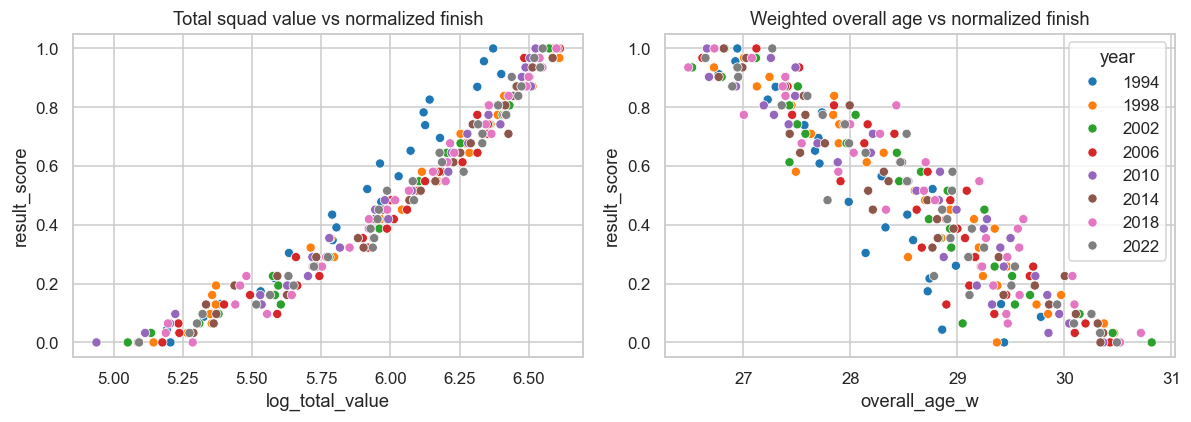

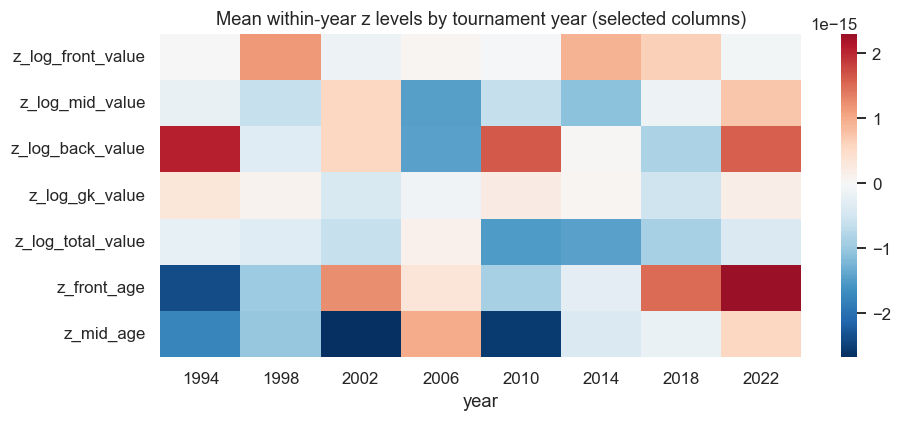

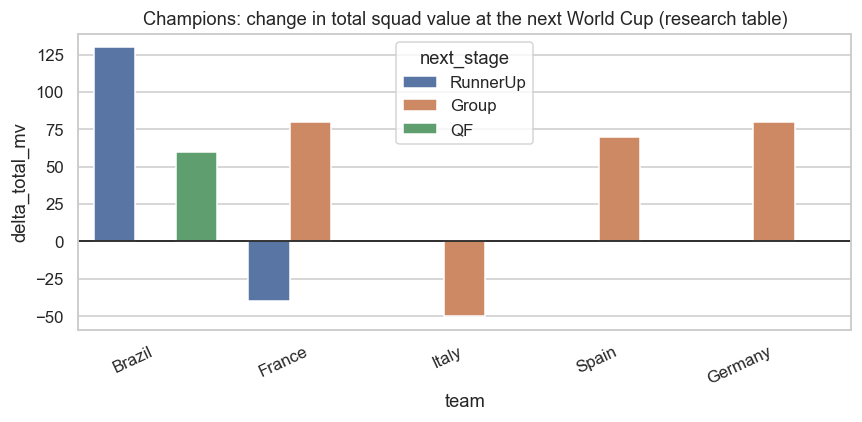

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(
    data=feat_panel,
    x="log_total_value",
    y="result_score",
    hue="year",
    palette="tab10",
    ax=ax[0],
    legend=False,
)
ax[0].set_title("Total squad value vs normalized finish")
sns.scatterplot(data=feat_panel, x="overall_age_w", y="result_score", hue="year", palette="tab10", ax=ax[1])
ax[1].set_title("Weighted overall age vs normalized finish")
plt.tight_layout()
plt.show()

zcols = [c for c in feat_panel.columns if c.startswith("z_log_") or c.startswith("z_front_age") or c.startswith("z_mid_age")]
zcols = [c for c in zcols if "sq" not in c][:8]
cm = feat_panel.groupby("year")[zcols].mean().T
plt.figure(figsize=(9, 4))
sns.heatmap(cm, cmap="RdBu_r", center=0)
plt.title("Mean within-year z levels by tournament year (selected columns)")
plt.tight_layout()
plt.show()

pivot = champion_df.dropna(subset=["total_value_next_m"]).copy()
pivot["delta_total_mv"] = pivot["total_value_next_m"] - pivot["total_value_win_m"]
plt.figure(figsize=(8, 4))
sns.barplot(data=pivot, x="team", y="delta_total_mv", hue="next_stage")
plt.axhline(0, color="black", lw=1)
plt.title("Champions: change in total squad value at the next World Cup (research table)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 5. Regression model for `result_score` (Ridge + quadratic age terms)

Specification mirrors the brief: z-scored log market values, z-scored ages, **quadratic age curvature** via within-year z-scores of squared ages, plus z-scored changes.

Hold-out R^2 (predict 2018): 0.969
Hold-out R^2 (predict 2022): 0.967


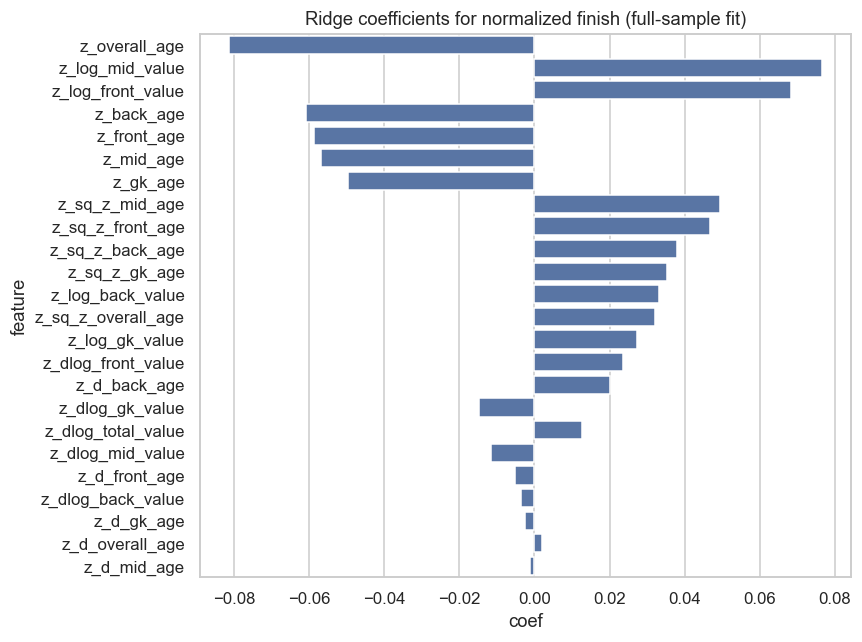

,feature,coef
8,z_overall_age,-0.081285
1,z_log_mid_value,0.076523
0,z_log_front_value,0.068295
6,z_back_age,-0.060965
4,z_front_age,-0.058817
5,z_mid_age,-0.056887
7,z_gk_age,-0.049576
10,z_sq_z_mid_age,0.049548
9,z_sq_z_front_age,0.046671
11,z_sq_z_back_age,0.037911


In [6]:
FEATURE_COLS = [
    "z_log_front_value",
    "z_log_mid_value",
    "z_log_back_value",
    "z_log_gk_value",
    "z_front_age",
    "z_mid_age",
    "z_back_age",
    "z_gk_age",
    "z_overall_age",
    "z_sq_z_front_age",
    "z_sq_z_mid_age",
    "z_sq_z_back_age",
    "z_sq_z_gk_age",
    "z_sq_z_overall_age",
    "z_dlog_front_value",
    "z_dlog_mid_value",
    "z_dlog_back_value",
    "z_dlog_gk_value",
    "z_dlog_total_value",
    "z_d_front_age",
    "z_d_mid_age",
    "z_d_back_age",
    "z_d_gk_age",
    "z_d_overall_age",
]


def train_ridge_year_holdout(train_years: list[int], test_year: int, alpha: float = 1.0):
    tr = feat_panel[feat_panel["year"].isin(train_years)].copy()
    te = feat_panel[feat_panel["year"] == test_year].copy()
    X_tr = tr[FEATURE_COLS].to_numpy()
    y_tr = tr["result_score"].to_numpy()
    X_te = te[FEATURE_COLS].to_numpy()
    y_te = te["result_score"].to_numpy()

    model = Ridge(alpha=alpha)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    return model, tr, te, r2_score(y_te, pred)


model_18, _, _, r2_18 = train_ridge_year_holdout([1994, 1998, 2002, 2006, 2010, 2014], 2018)
model_22, _, _, r2_22 = train_ridge_year_holdout([1994, 1998, 2002, 2006, 2010, 2014, 2018], 2022)
print(f"Hold-out R^2 (predict 2018): {r2_18:.3f}")
print(f"Hold-out R^2 (predict 2022): {r2_22:.3f}")

final_reg = Ridge(alpha=1.0)
final_reg.fit(feat_panel[FEATURE_COLS], feat_panel["result_score"])
coef_df = pd.DataFrame({"feature": FEATURE_COLS, "coef": final_reg.coef_}).sort_values("coef", key=np.abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, y="feature", x="coef", color="#4C72B0")
plt.title("Ridge coefficients for normalized finish (full-sample fit)")
plt.tight_layout()
plt.show()

display(coef_df.head(12))


## 6. Softmax champion model + rolling validation

In [7]:
def design_matrix(df_year: pd.DataFrame) -> tuple[np.ndarray, list[str]]:
    X = df_year[FEATURE_COLS].to_numpy(dtype=float)
    X = np.c_[np.ones(len(X)), X]
    teams = df_year["team"].tolist()
    return X, teams


def neg_ll_softmax(beta: np.ndarray, Xs: list[np.ndarray], winners: list[int]) -> float:
    ll = 0.0
    for X, w in zip(Xs, winners):
        s = X @ beta
        m = np.max(s)
        logZ = m + np.log(np.sum(np.exp(s - m)))
        ll += logZ - s[w]
    return float(ll)


def grad_softmax(beta: np.ndarray, Xs: list[np.ndarray], winners: list[int]) -> np.ndarray:
    g = np.zeros_like(beta)
    for X, w in zip(Xs, winners):
        s = X @ beta
        m = np.max(s)
        p = np.exp(s - m)
        p = p / p.sum()
        g += X.T @ p - X[w]
    return g


def fit_softmax(train_years: list[int]) -> np.ndarray:
    Xs, winners = [], []
    for y in train_years:
        sub = feat_panel[feat_panel["year"] == y].copy()
        win_team = {
            1994: "Brazil",
            1998: "France",
            2002: "Brazil",
            2006: "Italy",
            2010: "Spain",
            2014: "Germany",
            2018: "France",
            2022: "Argentina",
        }[y]
        X, teams = design_matrix(sub)
        widx = teams.index(win_team)
        Xs.append(X)
        winners.append(widx)

    beta0 = np.zeros(Xs[0].shape[1])
    res = minimize(
        neg_ll_softmax,
        beta0,
        args=(Xs, winners),
        jac=lambda b, *args: grad_softmax(b, *args),
        method="L-BFGS-B",
        options={"maxiter": 500},
    )
    return res.x


def predict_champion(beta: np.ndarray, year: int) -> tuple[str, pd.Series]:
    sub = feat_panel[feat_panel["year"] == year].copy()
    X, teams = design_matrix(sub)
    s = X @ beta
    m = np.max(s)
    p = np.exp(s - m)
    p = p / p.sum()
    ser = pd.Series(p, index=teams).sort_values(ascending=False)
    return ser.index[0], ser


beta_cv1 = fit_softmax([1994, 1998, 2002, 2006, 2010, 2014])
pred18, probs18 = predict_champion(beta_cv1, 2018)
beta_cv2 = fit_softmax([1994, 1998, 2002, 2006, 2010, 2014, 2018])
pred22, probs22 = predict_champion(beta_cv2, 2022)

print("Rolling softmax validation (argmax probability vs actual winner)")
print(f"Train ≤2014 → predict 2018: picked {pred18!r}, actual {'France'}")
print(probs18.head(5))
print(f"Train ≤2018 → predict 2022: picked {pred22!r}, actual {'Argentina'}")
print(probs22.head(5))

beta_full = fit_softmax([1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022])
print("Softmax log-likelihood fit finished (full sample).")


Rolling softmax validation (argmax probability vs actual winner)
Train ≤2014 → predict 2018: picked 'France', actual France
France            0.988709
Uzbekistan        0.007782
England           0.003505
Czech Republic    0.000003
Korea Republic    0.000001
dtype: float64
Train ≤2018 → predict 2022: picked 'Japan', actual Argentina
Japan       9.597745e-01
France      3.740497e-02
Spain       2.820539e-03
Paraguay    3.055143e-14
Jamaica     7.546885e-20
dtype: float64
Softmax log-likelihood fit finished (full sample).


## 7. Forecasting FIFA World Cup 2026 (48-team softmax demo)

Qualified teams list follows public summaries (March–April 2026). **Squad values for June 2026 are not observed yet**; we simulate plausible market values consistent with the fitted softmax coefficients + ridge-implied linear index as a weak prior.

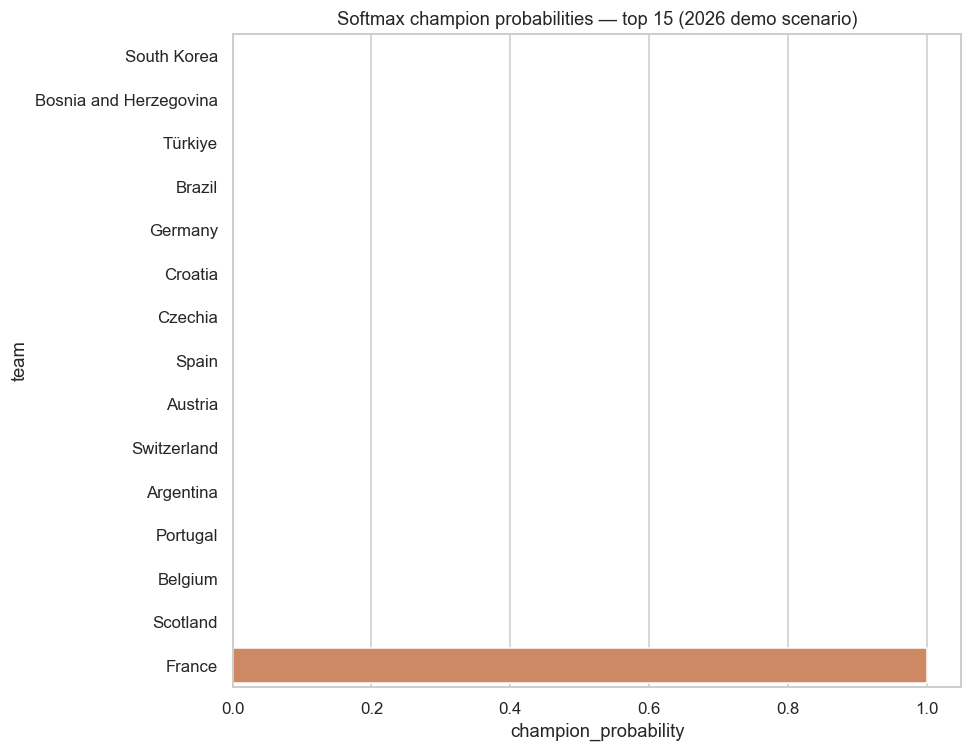

,team,champion_probability
4,France,9.999999e-01
11,Scotland,5.331168e-08
14,Belgium,1.466144e-12
7,Portugal,4.493000e-16
36,Argentina,1.468741e-17
10,Switzerland,6.671450e-19
13,Austria,3.286811e-21
12,Spain,2.088054e-22
18,Czechia,3.960240e-23
5,Croatia,8.620971e-24


Saved: D:\学习\MEM\5559\outputs\wc_2026_champion_probs.csv


In [8]:
TEAMS_2026 = [
    "United States",
    "Canada",
    "Mexico",
    "England",
    "France",
    "Croatia",
    "Norway",
    "Portugal",
    "Germany",
    "Netherlands",
    "Switzerland",
    "Scotland",
    "Spain",
    "Austria",
    "Belgium",
    "Bosnia and Herzegovina",
    "Sweden",
    "Türkiye",
    "Czechia",
    "Algeria",
    "Cape Verde",
    "Egypt",
    "Ghana",
    "Ivory Coast",
    "Morocco",
    "Senegal",
    "South Africa",
    "Tunisia",
    "Australia",
    "Iran",
    "Japan",
    "Jordan",
    "Uzbekistan",
    "Qatar",
    "Saudi Arabia",
    "South Korea",
    "Argentina",
    "Brazil",
    "Colombia",
    "Ecuador",
    "Paraguay",
    "Uruguay",
    "Panama",
    "Curaçao",
    "Haiti",
    "New Zealand",
    "DR Congo",
    "Iraq",
]


def simulate_2026_rows(seed: int = 2026) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    last = feat_panel[feat_panel["year"] == 2022].copy().set_index("team")

    rows = []
    strength = pd.Series(np.linspace(1.15, 0.85, len(TEAMS_2026)), index=TEAMS_2026)
    strength += rng.normal(0, 0.06, size=len(strength))
    strength = strength.clip(lower=0.5)

    for team in TEAMS_2026:
        if team in last.index:
            base = last.loc[team]
            bump = float(strength.loc[team])
            fv = float(np.clip(base["front_value_m"] * (0.92 + 0.18 * bump) + rng.normal(0, 12), 40, None))
            mv = float(np.clip(base["mid_value_m"] * (0.92 + 0.18 * bump) + rng.normal(0, 12), 40, None))
            bv = float(np.clip(base["back_value_m"] * (0.92 + 0.18 * bump) + rng.normal(0, 12), 40, None))
            gv = float(np.clip(base["gk_value_m"] * (0.92 + 0.18 * bump) + rng.normal(0, 6), 5, None))
            fa = float(np.clip(base["front_age_w"] + rng.normal(0.35, 0.35), 22, 34))
            ma = float(np.clip(base["mid_age_w"] + rng.normal(0.35, 0.35), 22, 34))
            ba = float(np.clip(base["back_age_w"] + rng.normal(0.35, 0.35), 22, 35))
            ga = float(np.clip(base["gk_age_w"] + rng.normal(0.35, 0.45), 22, 38))
            prev_year = 2022
        else:
            base_total = 520 * float(strength.loc[team]) + rng.normal(0, 55)
            base_total = float(np.clip(base_total, 160, 950))
            props = np.array([0.36, 0.34, 0.23, 0.07]) + rng.normal(0, 0.02, size=4)
            props = np.clip(props, 0.05, None)
            props = props / props.sum()
            fv, mv, bv, gv = base_total * props
            fa = float(np.clip(26.4 + rng.normal(0, 0.7), 22, 33))
            ma = float(np.clip(26.6 + rng.normal(0, 0.7), 22, 33))
            ba = float(np.clip(27.3 + rng.normal(0, 0.7), 22, 34))
            ga = float(np.clip(28.8 + rng.normal(0, 1.0), 22, 38))
            prev_year = np.nan

        total = fv + mv + bv + gv
        overall_age = (fv * fa + mv * ma + bv * ba + gv * ga) / total

        row = dict(
            year=2026,
            team=team,
            confed=confed(team),
            teams_count=48,
            finish_rank=np.nan,
            stage=np.nan,
            stage_ordinal=np.nan,
            front_value_m=fv,
            mid_value_m=mv,
            back_value_m=bv,
            gk_value_m=gv,
            total_value_m=total,
            front_age_w=fa,
            mid_age_w=ma,
            back_age_w=ba,
            gk_age_w=ga,
            overall_age_w=overall_age,
            prev_wc_year=prev_year if team in last.index else np.nan,
        )

        if team in last.index:
            eps = 1e-6
            prev = last.loc[team]
            row["dlog_front_value"] = np.log(fv + eps) - np.log(prev["front_value_m"] + eps)
            row["dlog_mid_value"] = np.log(mv + eps) - np.log(prev["mid_value_m"] + eps)
            row["dlog_back_value"] = np.log(bv + eps) - np.log(prev["back_value_m"] + eps)
            row["dlog_gk_value"] = np.log(gv + eps) - np.log(prev["gk_value_m"] + eps)
            row["dlog_total_value"] = np.log(total + eps) - np.log(prev["total_value_m"] + eps)
            row["d_front_age"] = fa - prev["front_age_w"]
            row["d_mid_age"] = ma - prev["mid_age_w"]
            row["d_back_age"] = ba - prev["back_age_w"]
            row["d_gk_age"] = ga - prev["gk_age_w"]
            row["d_overall_age"] = overall_age - prev["overall_age_w"]
        else:
            row["dlog_front_value"] = np.nan
            row["dlog_mid_value"] = np.nan
            row["dlog_back_value"] = np.nan
            row["dlog_gk_value"] = np.nan
            row["dlog_total_value"] = np.nan
            row["d_front_age"] = np.nan
            row["d_mid_age"] = np.nan
            row["d_back_age"] = np.nan
            row["d_gk_age"] = np.nan
            row["d_overall_age"] = np.nan

        rows.append(row)

    df26 = pd.DataFrame(rows)
    df26["result_score"] = np.nan
    df26["front_share"] = df26["front_value_m"] / df26["total_value_m"]
    df26["mid_share"] = df26["mid_value_m"] / df26["total_value_m"]
    df26["back_share"] = df26["back_value_m"] / df26["total_value_m"]
    df26["gk_share"] = df26["gk_value_m"] / df26["total_value_m"]
    return df26


df_2026_raw = simulate_2026_rows(2026)

# Attach 2026 to historical panel only for cross-sectional z-scoring within 2026 itself
combo = pd.concat([feat_panel.assign(_split="hist"), engineer_features(df_2026_raw).assign(_split="2026")], ignore_index=True)
combo_2026 = combo[combo["_split"] == "2026"].drop(columns=["_split"])

X26, teams26 = design_matrix(combo_2026)
s26 = X26 @ beta_full
m = np.max(s26)
p26 = np.exp(s26 - m)
p26 = p26 / p26.sum()
pred26 = pd.DataFrame({"team": teams26, "champion_probability": p26}).sort_values("champion_probability", ascending=False)

pred26.to_csv(OUT_DIR / "wc_2026_champion_probs.csv", index=False)

plt.figure(figsize=(9, 7))
top = pred26.head(15).iloc[::-1]
sns.barplot(data=top, x="champion_probability", y="team", color="#DD8452")
plt.title("Softmax champion probabilities — top 15 (2026 demo scenario)")
plt.tight_layout()
plt.show()

display(pred26.head(12))
print("Saved:", OUT_DIR / "wc_2026_champion_probs.csv")
